# CICIDS Preprocessing and model evaluation

Here as an initial step I'm importing all the necessary module required for preprocessinf and model evaluation

In [129]:
# Core ML imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# Your chosen models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


## Step 1 Loading the data

In [130]:
# Example: load one of the days
df = pd.read_csv(r"C:\Users\91733\Documents\senti\SentinelNet\data\Wednesday-workingHours.pcap_ISCX.csv")

print(df.shape)
print(df.head())


(692703, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 80           38308                   1   
1                389             479                  11   
2                 88            1095                  10   
3                389           15206                  17   
4                 88            1092                   9   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            6   
1                        5                          172   
2                        6                         3150   
3                       12                         3452   
4                        6                         3150   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             6                       6   
1                           326                      79   
2                          3150                    1575   
3                          6660    

## Step 2 Handling missing / infinite values

In [131]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [132]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,691406.000000,6.914060e+05,691406.000000,691406.000000,6.914060e+05,6.914060e+05,691406.000000,691406.000000,691406.000000,691406.000000,...,691406.000000,691406.000000,6.914060e+05,6.914060e+05,6.914060e+05,6.914060e+05,6.914060e+05,6.914060e+05,6.914060e+05,6.914060e+05
mean,5683.120410,2.805421e+07,9.570718,10.232957,5.561296e+02,1.702833e+04,234.028258,15.048008,60.665921,83.050292,...,6.132624,26.755827,9.241782e+04,4.769783e+04,1.630416e+05,6.327032e+04,2.215270e+07,4.752643e+05,2.256399e+07,2.177450e+07
std,15722.340146,4.278968e+07,747.898242,985.127233,6.169395e+03,2.243276e+06,604.234467,51.113069,157.770839,226.309897,...,715.825482,6.323615,7.013504e+05,4.746482e+05,1.095619e+06,6.056634e+05,3.814785e+07,4.492673e+06,3.850662e+07,3.810129e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,2.020000e+02,2.000000,1.000000,1.200000e+01,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,6.156100e+04,2.000000,2.000000,8.200000e+01,1.880000e+02,46.000000,0.000000,41.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,8.308687e+07,7.000000,6.000000,3.650000e+02,1.159500e+04,341.000000,32.000000,56.833333,129.046988,...,2.000000,32.000000,9.920000e+02,0.000000e+00,9.920000e+02,9.890000e+02,1.600000e+07,0.000000e+00,1.810000e+07,1.000000e+07
max,65487.000000,1.200000e+08,203943.000000,272353.000000,1.224076e+06,6.270000e+08,24820.000000,2065.000000,4640.757576,6429.190773,...,197124.000000,60.000000,1.000000e+08,7.420000e+07,1.050000e+08,1.000000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


## Step 3 Encode labels

In [133]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [134]:
# Strip spaces in all column names
df.columns = df.columns.str.strip()

# Now you should have 'Label' instead of ' Label'
print(df.columns)


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [135]:
print(df.columns.tolist())

df = pd.get_dummies(df, columns=['Label'])

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

## Step 4 Train-Test Split

In [136]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (553124, 78)
Test shape: (138282, 78)


## Step 5: Scaling and PCA

In [137]:
# 1. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)



## Step 6 Handle Class Imbalance (SMOTE)

CICIDS2017 is imbalanced (some attack types are rare).

Options:

 1. Use SMOTE (oversampling)

 2. Class weights in models (class_weight='balanced')

In [138]:

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


## Step 7 Model Trainig

In [139]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced", C=0.5
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42, max_depth=8, min_samples_split=10, min_samples_leaf=5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120, random_state=42, n_jobs=-1,
        max_depth=12, min_samples_split=10, min_samples_leaf=5,
        class_weight="balanced_subsample"
    )
}




In [140]:
print("=== Multi-Class Metrics Evaluation ===")
for name, model in models.items():
    print(f"\nMODEL: {name}")
    start_time = time.time()
    model.fit(X_train_pca, y_train)
    end_time = time.time()
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    print(f"Testing Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    # Get classification report as dict
    report = classification_report(y_test, y_pred, output_dict=True)
    macro = report['macro avg']
    weighted = report['weighted avg']
    
    print("\nMacro Average Metrics:")
    print(f"  Precision: {macro['precision']:.4f} ({macro['precision']*100:.2f}%)")
    print(f"  Recall:    {macro['recall']:.4f} ({macro['recall']*100:.2f}%)")
    print(f"  F1-Score:  {macro['f1-score']:.4f} ({macro['f1-score']*100:.2f}%)")
    
    print("\nWeighted Average Metrics:")
    print(f"  Precision: {weighted['precision']:.4f} ({weighted['precision']*100:.2f}%)")
    print(f"  Recall:    {weighted['recall']:.4f} ({weighted['recall']*100:.2f}%)")
    print(f"  F1-Score:  {weighted['f1-score']:.4f} ({weighted['f1-score']*100:.2f}%)")
    
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

=== Multi-Class Metrics Evaluation ===

MODEL: Logistic Regression
Testing Accuracy: 0.9738 (97.38%)

Macro Average Metrics:
  Precision: 0.9687 (96.87%)
  Recall:    0.9757 (97.57%)
  F1-Score:  0.9720 (97.20%)

Weighted Average Metrics:
  Precision: 0.9744 (97.44%)
  Recall:    0.9738 (97.38%)
  F1-Score:  0.9739 (97.39%)

Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.9898    0.9689    0.9792     87937
           1     0.9475    0.9826    0.9647     50345

    accuracy                         0.9738    138282
   macro avg     0.9687    0.9757    0.9720    138282
weighted avg     0.9744    0.9738    0.9739    138282


MODEL: Decision Tree
Testing Accuracy: 0.9911 (99.11%)

Macro Average Metrics:
  Precision: 0.9902 (99.02%)
  Recall:    0.9906 (99.06%)
  F1-Score:  0.9904 (99.04%)

Weighted Average Metrics:
  Precision: 0.9911 (99.11%)
  Recall:    0.9911 (99.11%)
  F1-Score:  0.9911 (99.11%)

Detailed Classification Report:


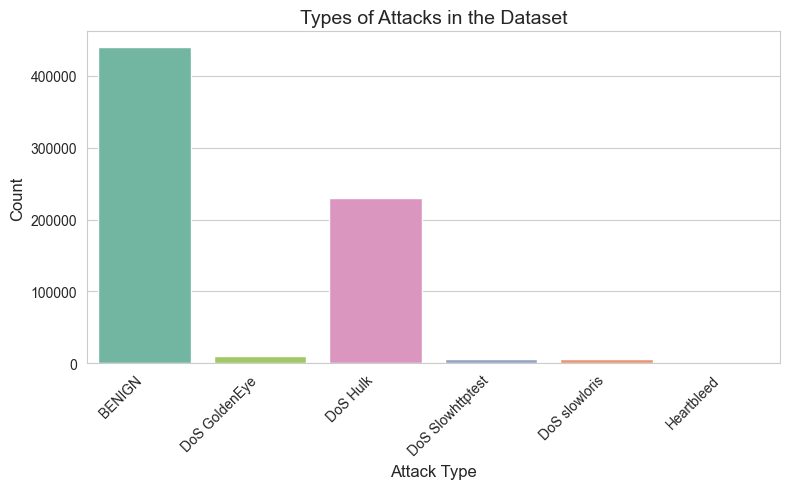

Types of attacks:
['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']


In [110]:
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Label_reconstructed',
    hue='Label_reconstructed',
    data=df,
    palette='Set2',
    order=sorted(df['Label_reconstructed'].unique()),
    legend=False
)
plt.title('Types of Attacks in the Dataset', fontsize=14)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

print("Types of attacks:")
print(df['Label_reconstructed'].unique())

## Accuaracy comparision

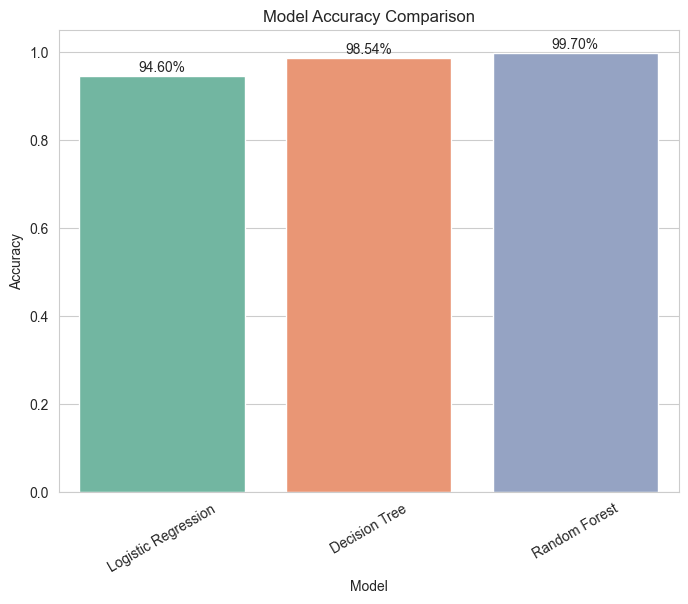

In [111]:

from sklearn.metrics import accuracy_score

results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results)
plt.figure(figsize=(8,6))
barplot = sns.barplot(
    x='Model', y='Accuracy', hue='Model',
    data=results_df, dodge=False, palette="Set2", legend=False
)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)

# Add percentage labels on top of bars
for bar in plt.gca().patches:
    height = bar.get_height()
    plt.gca().text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height*100:.2f}%",
        ha='center'
    )
plt.show()


## Confusion matrix

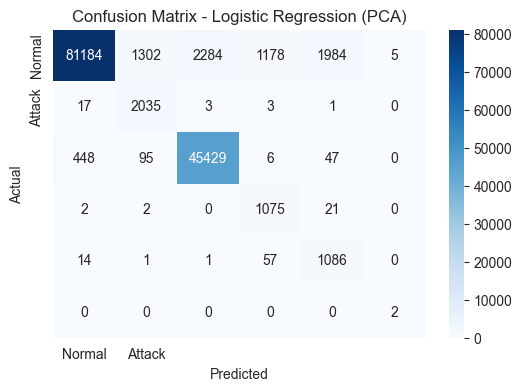

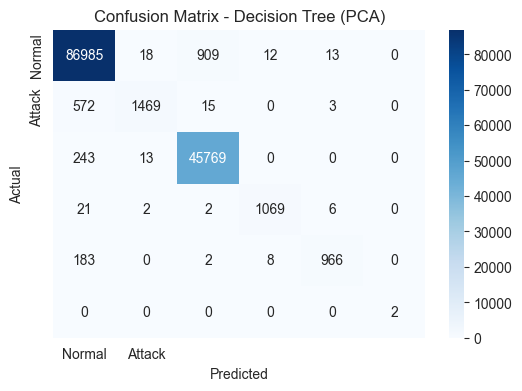

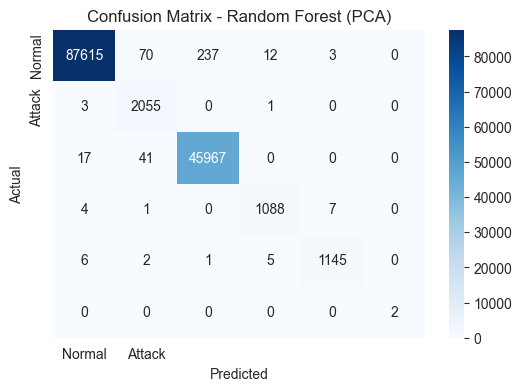

In [112]:
# Loop through all models and plot confusion matrix
for name, model in trained_models.items():
    y_pred = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    plt.title(f'Confusion Matrix - {name} (PCA)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()




## ROC Curve

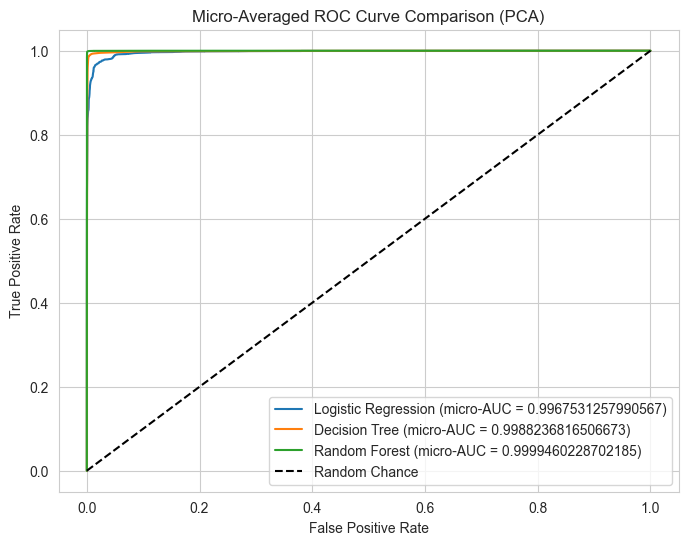

In [115]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))
for name, model in trained_models.items():
    y_probs = model.predict_proba(X_test_pca)
    # Compute micro-average ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_probs.ravel())
    auc_score = roc_auc_score(y_test_bin, y_probs, average="micro")
    plt.plot(fpr, tpr, label=f'{name} (micro-AUC = {auc_score:})')
plt.plot([0,1], [0,1], 'k--', label='Random Chance')
plt.title('Micro-Averaged ROC Curve Comparison (PCA)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Correlation HeatMap

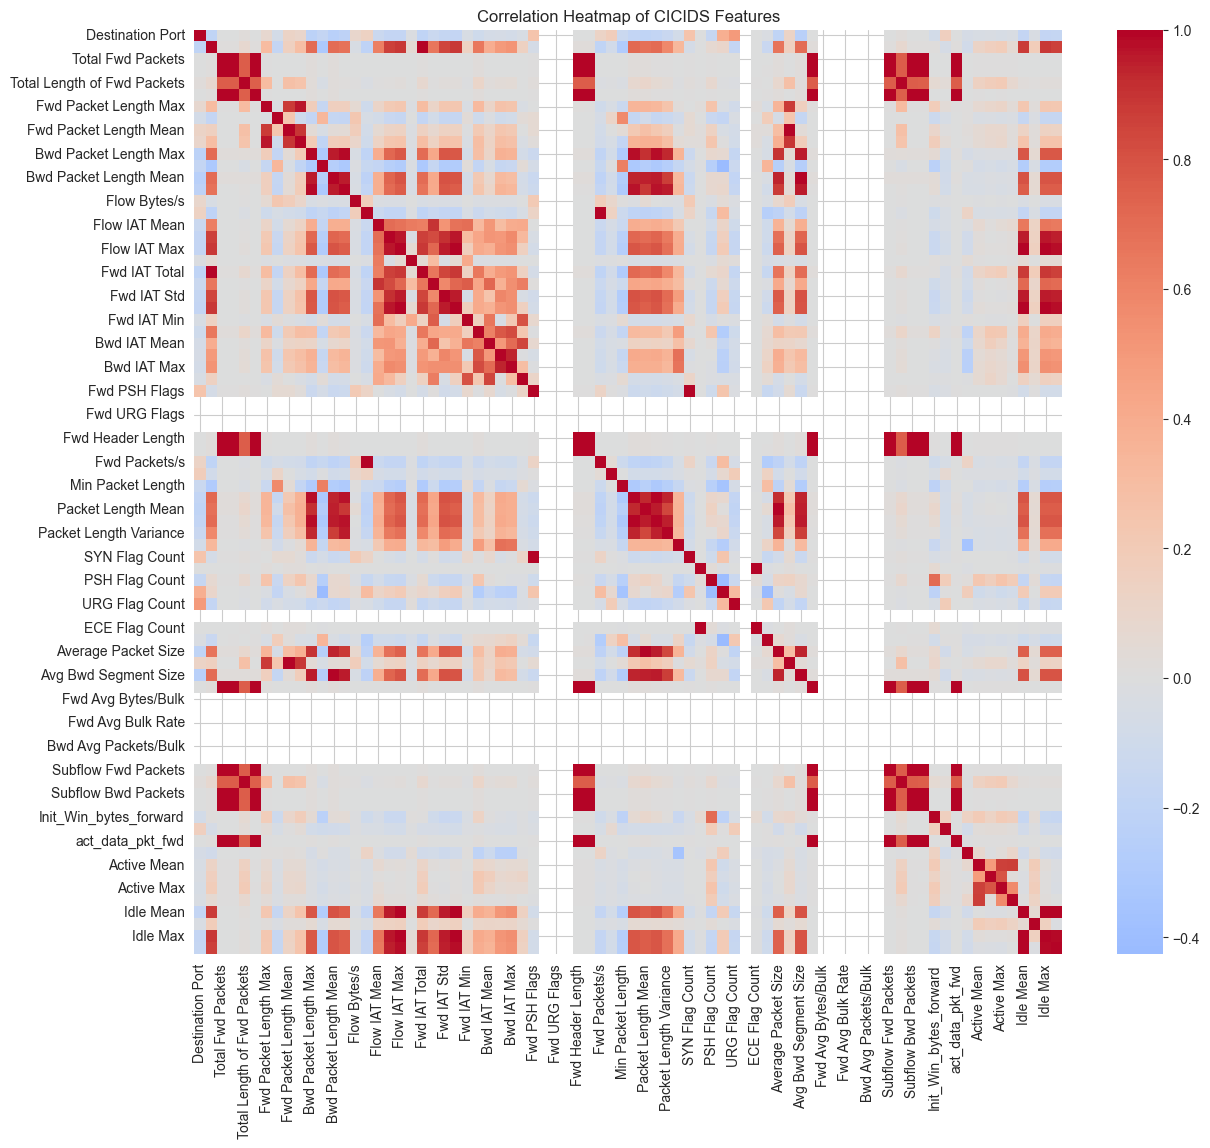

In [69]:
plt.figure(figsize=(14, 12))
corr_cicids = X_train.corr()
sns.heatmap(corr_cicids, cmap='coolwarm', center=0, annot=False, fmt=".2f", cbar=True)
plt.title('Correlation Heatmap of CICIDS Features')
plt.show()


## Binary Classification

In [117]:
# Get all label columns
label_cols = [col for col in df.columns if col.startswith('Label_')]

# Create binary label: 0 for Normal, 1 for Attack
df['Binary_Label'] = (df['Label_reconstructed'] != 'BENIGN').astype(int)

# Use Binary_Label as target
X = df.drop(label_cols + ['Label_reconstructed', 'Binary_Label'], axis=1)
y = df['Binary_Label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

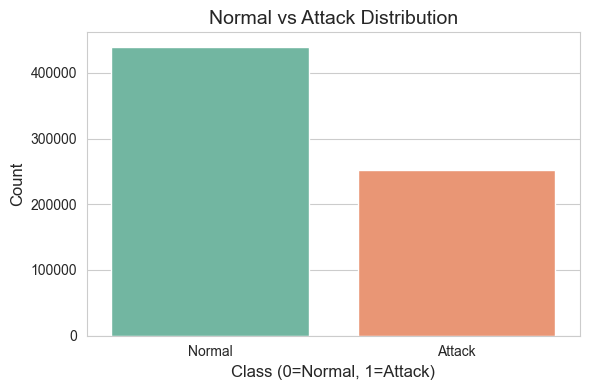

Class counts:
Binary_Label
0    439683
1    251723
Name: count, dtype: int64


In [119]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Binary_Label', hue='Binary_Label', data=df, palette='Set2', legend=False)
plt.title('Normal vs Attack Distribution', fontsize=14)
plt.xlabel('Class (0=Normal, 1=Attack)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Normal', 'Attack'], fontsize=10)
plt.tight_layout()
plt.show()

print("Class counts:")
print(df['Binary_Label'].value_counts())

== Logistic Regression ==


c:\Users\91733\Documents\senti\SentinelNet\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8992710548010587
Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.91      0.92     87937
      Attack       0.85      0.88      0.86     50345

    accuracy                           0.90    138282
   macro avg       0.89      0.90      0.89    138282
weighted avg       0.90      0.90      0.90    138282



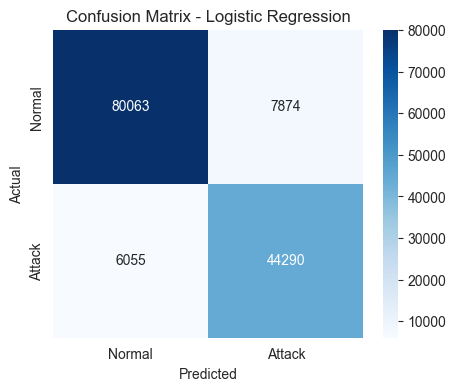

== Decision Tree ==
Accuracy: 0.9940411622626227
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     87937
      Attack       0.99      0.99      0.99     50345

    accuracy                           0.99    138282
   macro avg       0.99      0.99      0.99    138282
weighted avg       0.99      0.99      0.99    138282



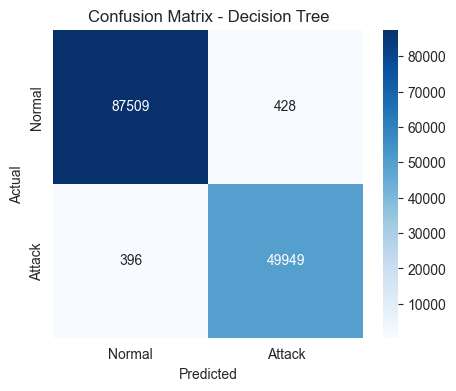

== Random Forest ==
Accuracy: 0.9987850913350979
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     87937
      Attack       1.00      1.00      1.00     50345

    accuracy                           1.00    138282
   macro avg       1.00      1.00      1.00    138282
weighted avg       1.00      1.00      1.00    138282



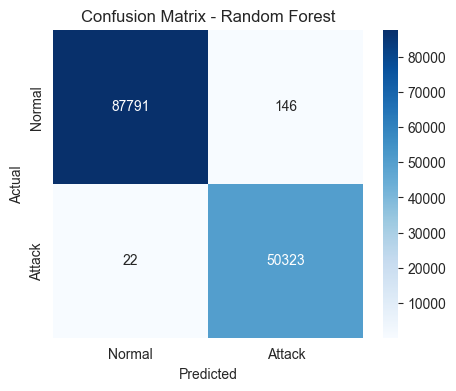

In [123]:
results = []

for name, model in models.items():
    print(f"== {name} ==")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # Store results
    results.append({"Model": name, "Accuracy": acc})

# You can now use 'results' for further visualization

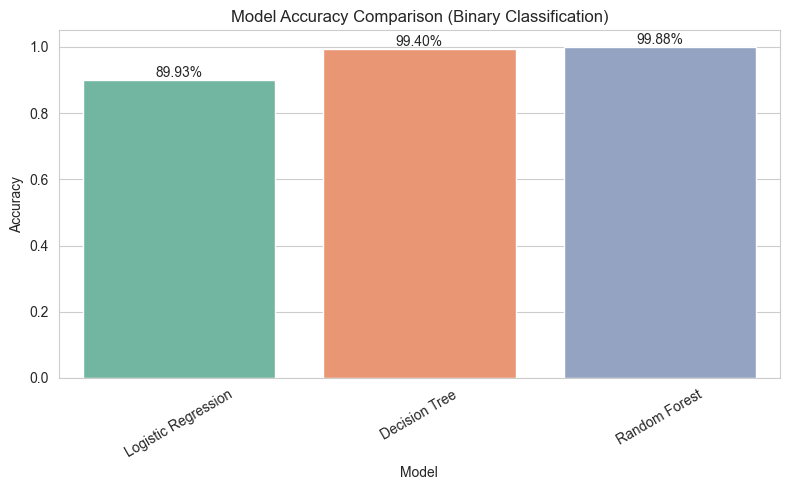

In [125]:


results_df = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=results_df, dodge=False, palette='Set2', legend=False)
plt.title('Model Accuracy Comparison (Binary Classification)')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)

# Add percentage labels on top of bars
for bar in plt.gca().patches:
    height = bar.get_height()
    plt.gca().text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height*100:.2f}%",
        ha='center'
    )
plt.tight_layout()
plt.show()

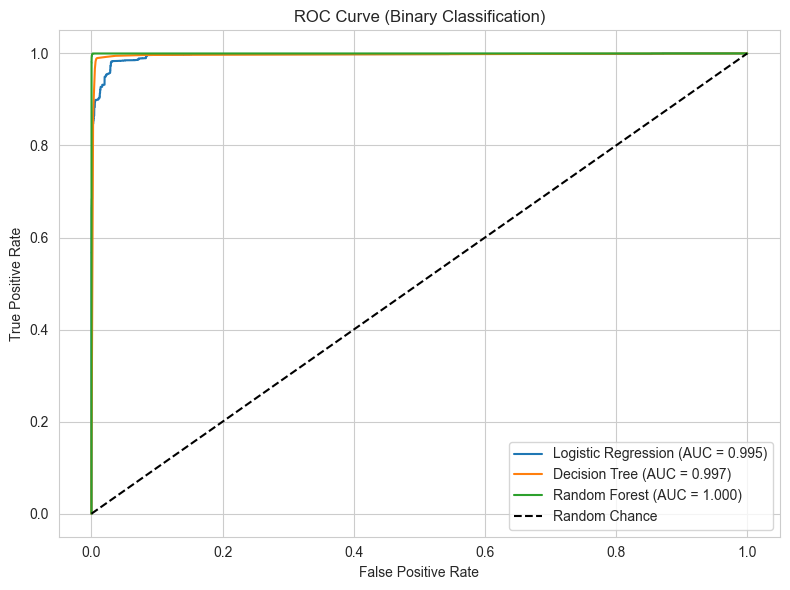

In [142]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_pca)[:, 1]
    else:
        y_prob = model.decision_function(X_test_pca)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve (Binary Classification)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

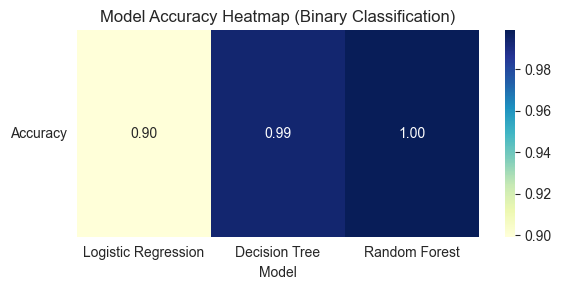

In [126]:
plt.figure(figsize=(6, 3))
sns.heatmap(
    results_df.set_index('Model').T, 
    annot=True, fmt=".2f", cmap="YlGnBu", cbar=True
)
plt.title('Model Accuracy Heatmap (Binary Classification)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()